# Oprimization of LSTM and GRU

In [1]:
from scipy.io import loadmat
from numpy import asarray
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy.matlib
from scipy import signal
from scipy.signal import welch
from scipy.stats import entropy
from scipy.fft import fft, fftfreq
import os
import glob
from warnings import warn
from sklearn import metrics
plt.rc('font',family='Times New Roman')
import warnings 
warnings.filterwarnings('ignore')

In [2]:
def make_dataset(data_src):
    files = glob.glob(data_src)
    dataset_df = []
    for file in files:
        if os.path.isfile(file) and file.endswith(".csv"):
            # read only the 2nd column (index 1)
            col = pd.read_csv(file, header=None, usecols=[1])
            dataset_df.append(col)
    
    dataset = pd.concat(dataset_df, ignore_index=True, axis=1)
    return dataset.T

## Dataset

In [19]:
data_path = ("../data/Wave Data/") # path to the 4 folders.
A  = make_dataset(os.path.join(data_path,  'A/*'))
B  = make_dataset(os.path.join(data_path,  'B/*'))
C  = make_dataset(os.path.join(data_path,  'C/*'))
D  = make_dataset(os.path.join(data_path,  'D/*'))
E  = make_dataset(os.path.join(data_path,  'E/*'))

In [20]:
normal = pd.concat([A, B, C, D]).reset_index(drop=True).to_numpy()
ictal = E.to_numpy()

In [21]:
num_samples =500 # Length of input segment
###########################################
fs =  173.61; # Sampling freq.

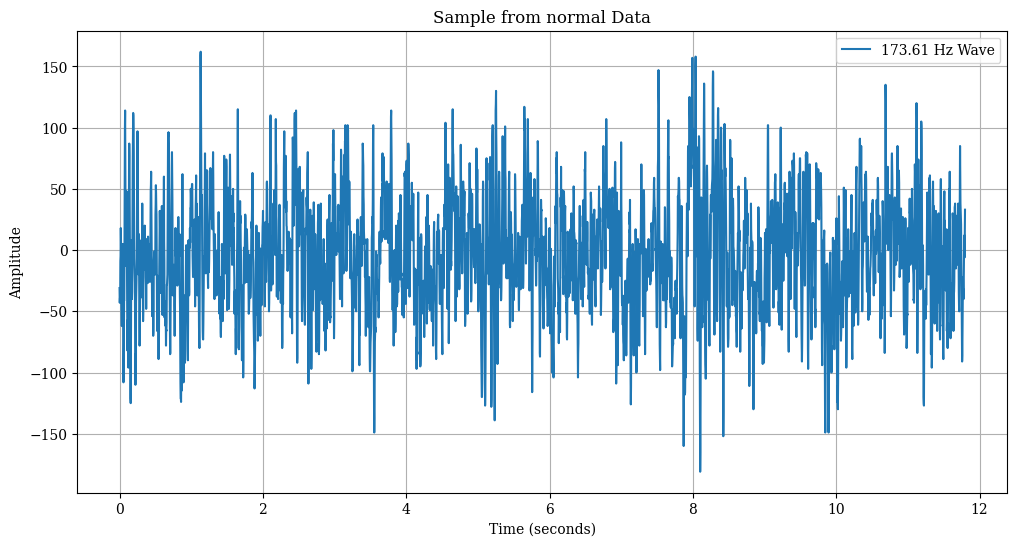

In [27]:
plt.rcParams["font.family"] = "DejaVu Serif"
num_points = 4097
sampling_rate = 2 * fs
t = np.arange(num_points) / sampling_rate
signal = normal[0]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(t, signal, label=f"{fs} Hz Wave")
plt.title("Sample from normal Data")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

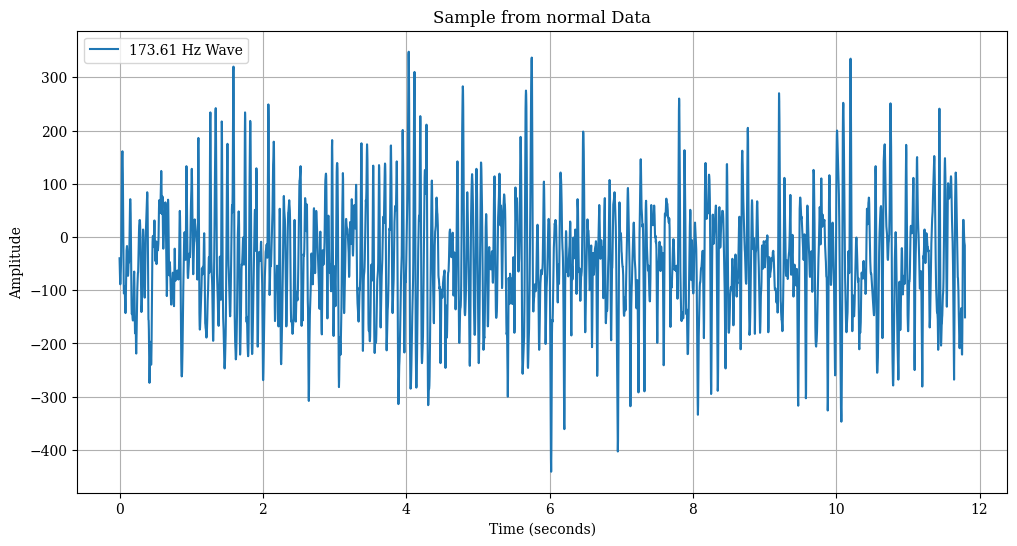

In [28]:
signal = ictal[0]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(t, signal, label=f"{fs} Hz Wave")
plt.title("Sample from normal Data")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
normal_labels = np.zeros(len(normal))
ictal_labels = np.ones(len(ictal))

# Combine data and labels
X = np.concatenate((normal, ictal), axis=0)
Y = np.concatenate((normal_labels, ictal_labels), axis=0)

print("Dataset features size:", X.shape)
print("Dataset labels size:", Y.shape)

Dataset features size: (500, 4097)
Dataset labels size: (500,)


In [30]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, 
                                                    shuffle = True, stratify = Y, random_state = 42)

In [32]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, shuffle = True, stratify = y_train, random_state=42)

In [33]:
mean = X_train.mean(axis=(0, 1), keepdims=True)  
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8  

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std
X_val_norm = (X_val - mean) / std

In [34]:
X_train = np.reshape(X_train_norm, (X_train_norm.shape[0], X_train_norm.shape[1], 1))
X_test = np.reshape(X_test_norm, (X_test_norm.shape[0], X_test_norm.shape[1], 1))
X_val = np.reshape(X_val_norm, (X_val_norm.shape[0], X_val_norm.shape[1], 1))

In [35]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.config.experimental import list_physical_devices, set_memory_growth
from tensorflow import device
from tensorflow.keras.callbacks import ModelCheckpoint
from hyperopt import tpe, hp, fmin, Trials
import numpy as np

2025-08-30 17:18:05.720520: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-30 17:18:06.032099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756574286.144248     741 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756574286.173704     741 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-30 17:18:06.465213: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Optimize LSTM

In [37]:
timesteps = 4097
features = 1
def objective(params):
    model = Sequential([
        LSTM(params['units0'], return_sequences=True, input_shape=(timesteps, features), recurrent_dropout=params['rd0']),  
        LSTM(params['units1'], return_sequences=True, recurrent_dropout=params['rd1']),
        LSTM(params['units2'], return_sequences=False, recurrent_dropout=params['rd2']),
        Dropout(params['dropout0']),
        Dense(params['dense_units'], activation='relu'), 
        Dropout(params['dropout1']),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=params['lr']), loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    with device('/GPU:0'):
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size = 20,
            callbacks= [early_stopping],
            verbose = 0
        )
    val_loss = history.history['val_loss'][-1]
    return val_loss

In [38]:
space = {
    'units0': hp.choice('units0', [16, 32, 64, 128]),
    'units1': hp.choice('units1', [16, 32, 64, 128]),
    'units2': hp.choice('units2', [16, 32, 64, 128]),
    'rd0': hp.uniform('rd0', 0.1, 0.5),
    'rd1': hp.uniform('rd1', 0.1, 0.5),
    'rd2': hp.uniform('rd2', 0.1, 0.5),
    'dropout0': hp.uniform('dropout0', 0.1, 0.5),
    'dropout1': hp.uniform('dropout1', 0.1, 0.5),
    'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-2)),
    'dense_units': hp.choice('dense_units', [16, 32, 64, 128]),
}

In [ ]:
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials
)

print("Best hyperparameters:", best)

  0%|                                                                    | 0/20 [00:00<?, ?trial/s, best loss=?]

I0000 00:00:1756574303.796622     741 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [96]:
print(best)

NameError: name 'best' is not defined

In [98]:
vals = {
    'units0': [16, 32, 64, 128],
    'units1': [16, 32, 64, 128],
    'units2': [16, 32, 64, 128],
    'dense_units': [16, 32, 64, 128],
}

In [99]:
model = Sequential([
    LSTM(vals['units0'][best['units0']], return_sequences=True, input_shape=(timesteps, features), recurrent_dropout=best['rd0']),  
    LSTM(vals['units1'][best['units1']], return_sequences=True, recurrent_dropout=best['rd1']),
    LSTM(vals['units2'][best['units2']], return_sequences=False, recurrent_dropout=best['rd2']),
    Dropout(best['dropout0']),
    Dense(vals['dense_units'][best['dense_units']], activation='relu'), 
    Dropout(best['dropout1']),
    Dense(1, activation='softmax')
])
model.compile(optimizer=Adam(learning_rate = best['lr']), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    '../weights/Optimized_LSTM.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

In [100]:
with device('/GPU:0'):
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size = 20,
        callbacks= [early_stopping, checkpoint]
    )


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1174s 73s/step - accuracy: 0.2133 - loss: 0.6925 - val_accuracy: 0.2000 - val_loss: 0.6912
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1145s 72s/step - accuracy: 0.2143 - loss: 0.6914 - val_accuracy: 0.2000 - val_loss: 0.6892
Epoch 3/50
 7/16 ━━━━━━━━━━━━━━━━━━━━ 11:06 74s/step - accuracy: 0.1981 - loss: 0.6915

KeyboardInterrupt: 

In [26]:
model.load_weights('../weights/Optimized_LSTM.weights.h5')
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1755 - loss: 0.3911
Test Loss: 0.4337286055088043
Test Accuracy: 0.1991869956254959


In [27]:
y_pred = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

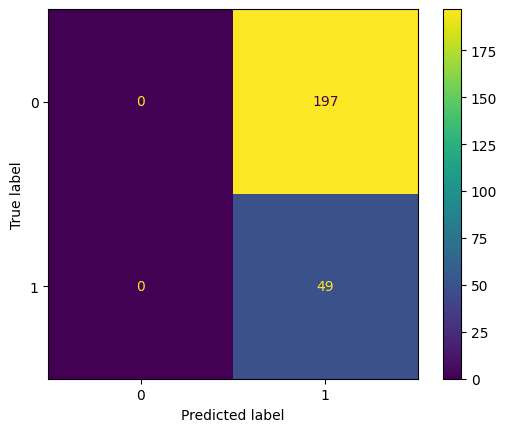

In [30]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
display_labels = [0, 1]  # Adjust based on your class labels
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       197
         1.0       0.20      1.00      0.33        49

    accuracy                           0.20       246
   macro avg       0.10      0.50      0.17       246
weighted avg       0.04      0.20      0.07       246



## Optimize GRU

In [40]:
def objective_GRU(params):
    model = Sequential([
        GRU(params['units0'], return_sequences=True, input_shape=(timesteps, features), recurrent_dropout=params['rd0']),  
        GRU(params['units1'], return_sequences=True, recurrent_dropout=params['rd1']),
        GRU(params['units2'], return_sequences=False, recurrent_dropout=params['rd2']),
        Dropout(params['dropout0']),
        Dense(params['dense_units'], activation='relu'), 
        Dropout(params['dropout1']),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=params['lr']), loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    with device('/GPU:0'):
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size = 20,
            callbacks= [early_stopping],
            verbose = 0
        )
    val_loss = history.history['val_loss'][-1]
    return val_loss

In [41]:
trials_GRU = Trials()

best_GRU = fmin(
    fn=objective_GRU,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials_GRU
)

print("Best hyperparameters:", best_GRU)

 20%|████████▏                                | 4/20 [04:51<19:24, 72.78s/trial, best loss: 0.07104545831680298]


KeyboardInterrupt: 

In [ ]:
print(best_GRU)

In [ ]:
model_GRU = Sequential([
    GRU(vals['units0'][best_GRU['units0']], return_sequences=True, input_shape=(timesteps, features),recurrent_dropout=best['rd0']),  
    GRU(vals['units1'][best_GRU['units1']], return_sequences=True, recurrent_dropout=best['rd1']),
    GRU(vals['units2'][best_GRU['units2']], return_sequences=False, recurrent_dropout=best['rd2']),
    Dropout(best_GRU['dropout0']),
    Dense(vals['dense_units'][best_GRU['dense_units']], activation='relu'), 
    Dropout(best_GRU['dropout1']),
    Dense(1, activation='sigmoid')
])
model_GRU.compile(optimizer=Adam(learning_rate = best_GRU['lr']), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    '../weights/Optimized_GRU.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

In [ ]:
with device('/GPU:0'):
    history = model_GRU.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size = 20,
        callbacks= [early_stopping, checkpoint]
    )

In [ ]:
model_GRU.load_weights('../weights/Optimized_GRU.weights.h5')
test_loss, test_accuracy = model_GRU.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

In [ ]:
y_pred = model_GRU.predict(X_test)

In [ ]:
# Converting to class labels
y_test = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred, axis=1)

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
display_labels = [0, 1, 2]  # Adjust based on your class labels
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()